# Figure 8.6: Decoding latent vector centroids.

Calculation and reconstruction of global average latent vectors from the MNIST autoencoder embedding.

In [1]:
%matplotlib widget
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2DTranspose, ReLU
from tensorflow.keras.datasets import mnist
from pathlib import Path

np.random.seed(42)
tf.random.set_seed(42)

# ─────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────
RESULTS_DIR       = Path("..") / "data" / "mnist-ae"
LATENTS_H5        = RESULTS_DIR / "latents.h5"
DECODER_WEIGHTS   = RESULTS_DIR / "decoder_weights.h5"

# Must match training
N_LAYERS      = 2
BASE_FILTERS  = 16
LATENT_DIM    = 64

# Geometric median settings
GEOMED_MAX_ITERS = 1000
GEOMED_TOL       = 1e-7
GEOMED_SUBSAMPLE = None

# ─────────────────────────────────────────────────────────
# Load latents
# ─────────────────────────────────────────────────────────
with h5py.File(LATENTS_H5, "r") as hf:
    Z = hf["z"][:].astype(np.float32)

# ─────────────────────────────────────────────────────────
# Build and load decoder
# ─────────────────────────────────────────────────────────
def build_decoder(n_layers=2, base_filters=16, latent_dim=64):
    latent_in = Input((latent_dim,), name="z_sampling")
    spatial   = 28 // (2**n_layers)
    channels  = base_filters * (2**(n_layers-1))
    
    x = Dense(spatial * spatial * channels)(latent_in)
    x = Reshape((spatial, spatial, channels))(x)
    
    for i in reversed(range(n_layers)):
        f = base_filters * (2**i)
        x = Conv2DTranspose(f, 3, strides=(2,2), padding="same")(x)
        x = ReLU()(x)
    
    out = tf.keras.layers.Conv2D(1, 3, padding="same", activation="sigmoid", name="decoder_output")(x)
    return Model(latent_in, out, name="decoder")

decoder = build_decoder(N_LAYERS, BASE_FILTERS, LATENT_DIM)
decoder.load_weights(DECODER_WEIGHTS)

# ─────────────────────────────────────────────────────────
# Compute central latents
# ─────────────────────────────────────────────────────────
def geometric_median(points, tol=1e-7, max_iters=1000):
    P = points.astype(np.float64)
    x = P.mean(axis=0)
    eps = 1e-12
    
    for _ in range(max_iters):
        diff = P - x
        d    = np.linalg.norm(diff, axis=1) + eps
        w    = 1.0 / d
        x_new = (w[:, None] * P).sum(axis=0) / w.sum()
        
        if np.linalg.norm(x_new - x) <= tol:
            return x_new.astype(np.float32)
        x = x_new
    
    return x.astype(np.float32)

mean_z   = Z.mean(axis=0)
median_z = np.median(Z, axis=0)

if GEOMED_SUBSAMPLE is None or GEOMED_SUBSAMPLE >= Z.shape[0]:
    gm_input = Z
else:
    sel = np.random.choice(Z.shape[0], GEOMED_SUBSAMPLE, replace=False)
    gm_input = Z[sel]

geom_median_z = geometric_median(gm_input, tol=GEOMED_TOL, max_iters=GEOMED_MAX_ITERS)

# ─────────────────────────────────────────────────────────
# Reconstruct from central latents
# ─────────────────────────────────────────────────────────
central_stack = np.stack([mean_z, median_z, geom_median_z], axis=0).astype(np.float32)
recons = decoder.predict(central_stack, verbose=0)
recons = np.squeeze(recons, axis=-1)

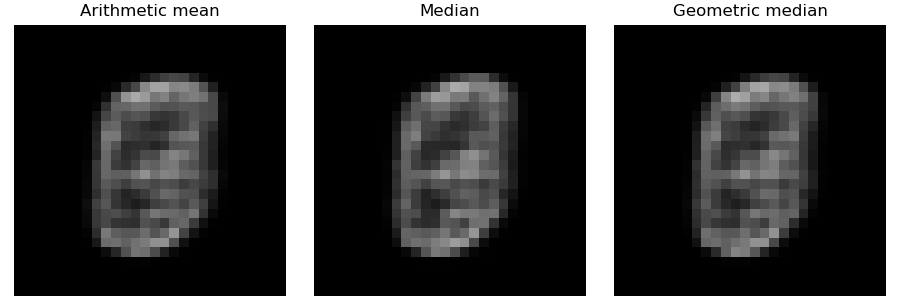

In [2]:
# ─────────────────────────────────────────────────────────
# Plot reconstructions
# ─────────────────────────────────────────────────────────
#| label: fig8f_data
METHOD_TITLES = ["Arithmetic mean", "Median", "Geometric median"]

fig, axes = plt.subplots(1, 3, figsize=(9, 3), constrained_layout=True)
for ax, img, title in zip(axes, recons, METHOD_TITLES):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
fig.canvas.header_visible = False
plt.show()